# ✅ Solutions — Module 6 — Hypothesis Testing

Worked solutions for every exercise of this module. **Try the exercise yourself first** — you learn statistics by *doing* it. Each solution ends with a short interpretation, because in real projects the numbers are only half of the answer.

*Every exercise is self-contained: run the setup cell below, then jump to any exercise.*

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

# --- additional tools for this module ---
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

### ✍️ Exercise 6.1 — *One-sample t-test*: Is the filling machine under-filling? (Food production / legal metrology)

A dairy fills bottles labelled **500 ml**. The quality team measures 25 randomly selected bottles from today's production. Under-filling risks fines from the weights-and-measures authority; over-filling gives product away.

**Tasks**
1. State $H_0$ and $H_1$ for a two-sided test and compute $t$ and $p$ by hand and with `stats.ttest_1samp`.
2. Give the 95 % CI for the mean fill volume. How does it relate to the test decision?
3. The authority only cares about *under*-filling. Run the appropriate one-sided test.
4. Check the normality assumption (Q–Q plot or Shapiro–Wilk).
5. What do you recommend to the production manager?

In [2]:
g = np.random.default_rng(601)
fill = pd.Series(g.normal(498.6, 2.8, 25).round(1), name="fill_ml")
print(fill.values)

[500.8 498.5 500.2 499.7 498.5 494.1 501.9 499.9 496.7 496.4 502.7 503.1
 498.8 499.5 499.8 496.1 497.6 498.1 500.9 494.9 496.3 499.2 495.6 497.1
 495.5]


mean = 498.48 ml, s = 2.43 ml, SE = 0.49
by hand: t = -3.134, p = 0.0045   |   scipy two-sided: t = -3.134, p = 0.0045
95 % CI for the mean: [497.47, 499.48] ml
one-sided (H1: mu < 500): p = 0.0023
Shapiro–Wilk normality test: p = 0.862


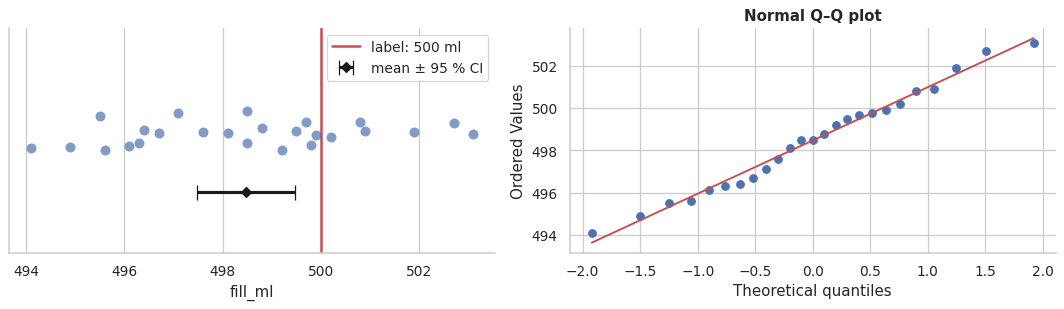

In [3]:
n, m, s = fill.size, fill.mean(), fill.std()
t_hand = (m - 500) / (s / np.sqrt(n)); p_hand = 2 * stats.t.sf(abs(t_hand), n - 1)
two = stats.ttest_1samp(fill, 500); one = stats.ttest_1samp(fill, 500, alternative="less")
ci = two.confidence_interval()
print(f"mean = {m:.2f} ml, s = {s:.2f} ml, SE = {s / np.sqrt(n):.2f}")
print(f"by hand: t = {t_hand:.3f}, p = {p_hand:.4f}   |   scipy two-sided: t = {two.statistic:.3f}, p = {two.pvalue:.4f}")
print(f"95 % CI for the mean: [{ci.low:.2f}, {ci.high:.2f}] ml")
print(f"one-sided (H1: mu < 500): p = {one.pvalue:.4f}")
print(f"Shapiro–Wilk normality test: p = {stats.shapiro(fill).pvalue:.3f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
sns.stripplot(x=fill, ax=a1, color=C[0], size=8, alpha=.7); a1.axvline(500, color=C[3], lw=2, label="label: 500 ml")
a1.errorbar([m], [.3], xerr=[[m - ci.low], [ci.high - m]], fmt="D", color="k", capsize=6, lw=2.5, label="mean ± 95 % CI"); a1.set(ylim=(.6, -.5)); a1.legend()
stats.probplot(fill, plot=a2); a2.set_title("Normal Q–Q plot"); plt.tight_layout(); plt.show()

**Interpretation.** The sample mean is about 1.5 ml below the label, which corresponds to $t \approx -3.1$: a deviation this large would be rare if the machine were centred at 500 ml (two-sided $p \approx 0.005$, one-sided half of that). Consistently, the 95 % CI (≈ 497.5–499.5 ml) **excludes 500** — test and interval always agree. Shapiro–Wilk and the Q–Q plot give no reason to doubt normality.

**Recommendation:** re-centre the machine by roughly +1.5 ml. *Statistical* significance is established; the *practical* relevance follows from regulation — and note that a legal requirement usually concerns individual bottles too (tolerance limits), which is a question about the spread, not only about the mean.

### ✍️ Exercise 6.2 — *Welch two-sample t-test*: Does the new drug lower blood pressure? (Clinical trial)

In a randomised, double-blind trial, patients received a new antihypertensive drug or a placebo for 8 weeks. The outcome is the **change in systolic blood pressure** (mmHg; negative = improvement). Clinicians regard a reduction of at least 5 mmHg relative to placebo as *clinically relevant*.

**Tasks**
1. Visualise both groups.
2. Test $H_0$: equal mean change, with Welch's test. Report the difference with 95 % CI.
3. Compute Cohen's $d$.
4. Is the effect statistically significant? Is it clinically relevant? Are these the same question?

In [4]:
g = np.random.default_rng(610)
bp = pd.DataFrame({"group": ["placebo"] * 42 + ["drug"] * 45,
                   "change_mmHg": np.concatenate([g.normal(-2.0, 11, 42), g.normal(-8.5, 13, 45)]).round(1)})
bp.groupby("group").change_mmHg.agg(["count", "mean", "std"]).round(2)

,count,mean,std
group,,,
drug,45,-7.96,14.46
placebo,42,-1.21,9.25


difference drug − placebo = -6.75 mmHg,  95 % CI [-11.90, -1.60]
Welch t = -2.61, df = 75.5, p = 0.0109
Cohen's d = -0.55


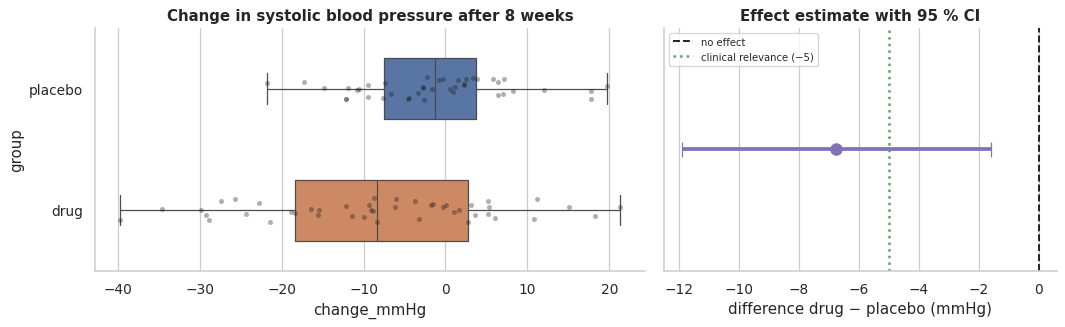

In [5]:
drug, placebo = bp.query("group == 'drug'").change_mmHg, bp.query("group == 'placebo'").change_mmHg
res = stats.ttest_ind(drug, placebo, equal_var=False); ci = res.confidence_interval()
diff = drug.mean() - placebo.mean()
s_pooled = np.sqrt(((drug.size - 1) * drug.var() + (placebo.size - 1) * placebo.var()) / (drug.size + placebo.size - 2))
print(f"difference drug − placebo = {diff:.2f} mmHg,  95 % CI [{ci.low:.2f}, {ci.high:.2f}]")
print(f"Welch t = {res.statistic:.2f}, df = {res.df:.1f}, p = {res.pvalue:.4f}")
print(f"Cohen's d = {diff / s_pooled:.2f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1.4, 1]})
sns.boxplot(bp, x="change_mmHg", y="group", ax=a1, palette=[C[0], C[1]], width=.5); sns.stripplot(bp, x="change_mmHg", y="group", ax=a1, color="k", alpha=.35, size=4)
a1.set_title("Change in systolic blood pressure after 8 weeks")
a2.errorbar([diff], [0], xerr=[[diff - ci.low], [ci.high - diff]], fmt="o", color=C[4], capsize=6, lw=3, ms=9)
a2.axvline(0, color="k", ls="--", label="no effect"); a2.axvline(-5, color=C[2], ls=":", lw=2, label="clinical relevance (−5)")
a2.set(yticks=[], xlabel="difference drug − placebo (mmHg)", title="Effect estimate with 95 % CI"); a2.legend(fontsize=8); plt.tight_layout(); plt.show()

**Interpretation.** Compare the confidence interval with *two* reference lines. It excludes 0 → the drug works better than placebo (statistically significant). Whether the effect is *clinically relevant* is a different question: the point estimate (≈ −6.8 mmHg) is beyond −5, but the interval (≈ −11.9 to −1.6) also contains values closer to zero than −5, so a merely modest benefit is still compatible with the data. Cohen's $d \approx -0.55$ is a "medium" effect: individual responses overlap heavily, as the boxplots show.

**Lesson:** report *estimate + interval* and discuss it against a pre-defined relevance threshold. "p < 0.05" alone answers a question nobody asked.

### ✍️ Exercise 6.3 — *Paired t-test*: Does the fuel additive pay off? (Fleet management)

A logistics company tests a fuel additive (cost: **€150 per van per year**). Each of 12 vans drives one month without and one month with the additive (order randomised). Vans differ strongly in consumption (route, load, driver). Each van drives about 40,000 km per year; diesel costs €1.60 per litre.

**Tasks**
1. Run the (wrong) independent-samples test and the (correct) paired test. Explain the difference.
2. Plot the paired data.
3. Give a 95 % CI for the mean saving in l/100 km and convert it to € per van per year.
4. Does the additive pay off?

In [6]:
g = np.random.default_rng(626)
van_level = g.normal(9.8, 1.6, 12)
fuel = pd.DataFrame({"van": [f"V{i + 1:02d}" for i in range(12)],
                     "without": (van_level + g.normal(0, .25, 12)).round(2),
                     "with_additive": (van_level - .35 + g.normal(0, .25, 12)).round(2)})
fuel

,van,without,with_additive
0,V01,11.81,11.22
1,V02,9.74,9.15
2,V03,8.74,8.24
3,V04,8.82,8.60
4,V05,12.14,11.77
5,V06,10.38,9.95
6,V07,9.41,9.73
7,V08,8.47,8.19
8,V09,9.54,9.05
9,V10,11.62,11.17


independent-samples (wrong): p = 0.515
paired (right)             : t = -4.95, p = 0.00044
mean change = -0.353 l/100 km, 95 % CI [-0.509, -0.196];  SD between vans = 1.33, SD of differences = 0.25
saving per van and year: 226 €  (95 % CI 125 … 326 €)  vs. cost 150 €


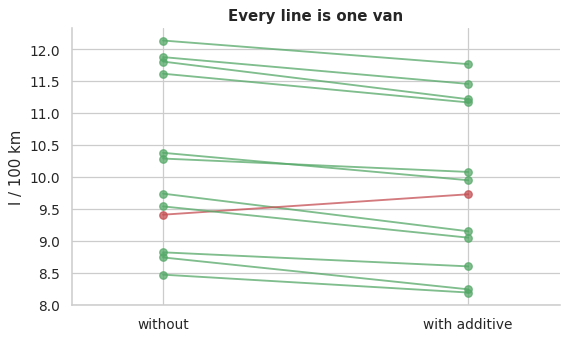

In [7]:
d = fuel.with_additive - fuel.without
print(f"independent-samples (wrong): p = {stats.ttest_ind(fuel.with_additive, fuel.without, equal_var=False).pvalue:.3f}")
res = stats.ttest_rel(fuel.with_additive, fuel.without); ci = res.confidence_interval()
print(f"paired (right)             : t = {res.statistic:.2f}, p = {res.pvalue:.5f}")
print(f"mean change = {d.mean():.3f} l/100 km, 95 % CI [{ci.low:.3f}, {ci.high:.3f}];  SD between vans = {fuel.without.std():.2f}, SD of differences = {d.std():.2f}")
eur = lambda l_per_100: -l_per_100 * 400 * 1.60           # 40,000 km = 400 × 100 km
print(f"saving per van and year: {eur(d.mean()):.0f} €  (95 % CI {eur(ci.high):.0f} … {eur(ci.low):.0f} €)  vs. cost 150 €")

fig, ax = plt.subplots(figsize=(7, 4))
for _, r in fuel.iterrows():
    ax.plot([0, 1], [r.without, r.with_additive], "o-", color=C[2] if r.with_additive < r.without else C[3], alpha=.75)
ax.set(xticks=[0, 1], xticklabels=["without", "with additive"], xlim=(-.3, 1.3), ylabel="l / 100 km", title="Every line is one van"); plt.show()

**Interpretation.** Treated as independent samples, the additive effect (≈ 0.3–0.4 l/100 km) drowns in the large differences *between* vans (SD ≈ 1.3 l) — p is far from significant. The paired analysis compares each van with itself; the SD of the differences is several times smaller and the same data yield strong evidence ($p < 0.001$).

**Business answer:** translate the interval, not just the mean, into money: the estimated saving is about €225 per van and year, with a 95 % CI of roughly €125–€325. The additive certainly *saves fuel*; whether it saves more than its €150 cost is likely (the point estimate is well above) but not yet certain, because the pessimistic end of the interval lies below the cost. A second test month would narrow the interval.

**Lesson:** design beats analysis. If you can measure the same unit under both conditions, do it — and analyse it as paired.

### ✍️ Exercise 6.4 — *Two-proportion z-test*: Did the redesigned checkout convert better? (E-commerce A/B test)

Visitors were randomly assigned to the current checkout (A) or a redesigned one (B).

**Tasks**
1. Compute both conversion rates, the absolute difference (percentage points) and the relative lift.
2. Compute the $z$ statistic by hand (pooled SE) and verify with `proportions_ztest`.
3. Give a 95 % CI for the absolute difference (unpooled SE).
4. Verify numerically that $z^2$ equals the $\chi^2$ statistic of the 2×2 table.
5. The redesign is only worth rolling out if it brings at least +0.2 percentage points. What is your recommendation?

In [8]:
visitors = np.array([15_230, 15_118])      # A, B
orders = np.array([594, 671])

conversion A = 3.90%, B = 4.44%;  difference = +0.54 pp;  relative lift = +13.8%
z by hand = 2.346;  statsmodels: z = 2.346, p = 0.0190;  chi2 = 5.502 = z² = 5.502
95 % CI for the difference: [+0.09, +0.99] percentage points


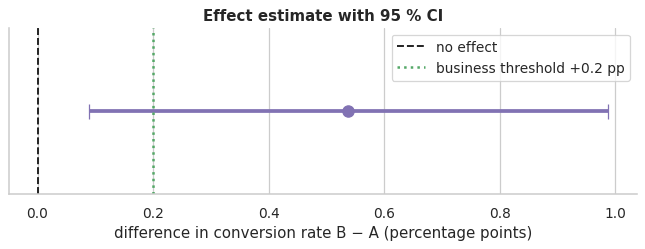

In [9]:
p = orders / visitors; diff = p[1] - p[0]
p_pool = orders.sum() / visitors.sum()
z_hand = diff / np.sqrt(p_pool * (1 - p_pool) * (1 / visitors).sum())
z, pval = proportions_ztest(orders[::-1], visitors[::-1])
se = np.sqrt((p * (1 - p) / visitors).sum()); lo, hi = diff - 1.96 * se, diff + 1.96 * se
chi2 = stats.chi2_contingency(np.array([orders, visitors - orders]), correction=False)[0]
print(f"conversion A = {p[0]:.2%}, B = {p[1]:.2%};  difference = {diff * 100:+.2f} pp;  relative lift = {p[1] / p[0] - 1:+.1%}")
print(f"z by hand = {z_hand:.3f};  statsmodels: z = {z:.3f}, p = {pval:.4f};  chi2 = {chi2:.3f} = z² = {z ** 2:.3f}")
print(f"95 % CI for the difference: [{lo * 100:+.2f}, {hi * 100:+.2f}] percentage points")
fig, ax = plt.subplots(figsize=(9, 2.4))
ax.errorbar([diff * 100], [0], xerr=[[(diff - lo) * 100], [(hi - diff) * 100]], fmt="o", color=C[4], capsize=6, lw=3, ms=9)
ax.axvline(0, color="k", ls="--", label="no effect"); ax.axvline(.2, color=C[2], ls=":", lw=2, label="business threshold +0.2 pp")
ax.set(yticks=[], xlabel="difference in conversion rate B − A (percentage points)", title="Effect estimate with 95 % CI"); ax.legend(); plt.show()

**Interpretation.** B converts at about 4.4 % versus 3.9 % — an absolute gain of roughly half a percentage point (≈ +14 % relative), $z \approx 2.3$, $p \approx 0.02$. The CI for the difference runs from about +0.1 to +1.0 pp: zero is excluded, but the business threshold of +0.2 pp lies *inside* the interval.

**Recommendation:** B is very likely better than A, and the most plausible gain (+0.5 pp) clearly exceeds the threshold; rolling out is a reasonable decision. If a wrong roll-out were expensive, continue the test until the lower end of the CI clears +0.2 pp. Again the interval carries the message — the p-value only says "not zero".

### ✍️ Exercise 6.5 — *Permutation test*: A new physiotherapy protocol with a tiny sample (Rehabilitation medicine)

A clinic pilots a new rehabilitation protocol after knee surgery. Outcome: days until the patient can walk stairs without aid. Samples are small and recovery times are right-skewed, so you do not want to lean on the $t$-distribution.

**Tasks**
1. Compute the observed difference in **means** and in **medians**.
2. Write a permutation test (10,000 shuffles) for the difference in means (two-sided).
3. Cross-check with `stats.permutation_test` and with Welch's $t$-test.
4. Repeat for the difference in medians. What do you conclude, and what would you advise the clinic?

In [10]:
g = np.random.default_rng(626)
standard = np.round(g.lognormal(np.log(30), .45, 10))
new = np.round(g.lognormal(np.log(21), .45, 9))
print("standard:", standard, "\nnew     :", new)

standard: [51. 30. 22. 22. 56. 33. 31. 20. 26. 52.] 
new     : [25. 37. 26. 19. 21. 26. 25. 31.  8.]


difference in means   =  -10.1 days, permutation p = 0.084  (scipy: 0.071, Welch t: 0.066)
difference in medians =   -5.5 days, permutation p = 0.251


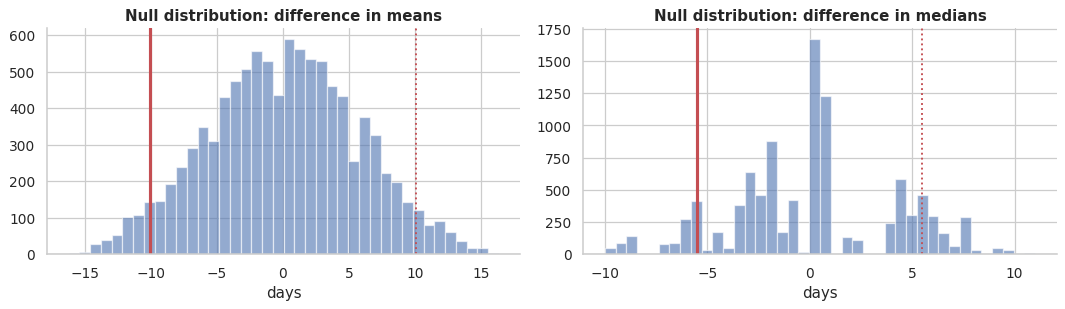

In [11]:
def perm_test(a, b, stat, B=10_000):
    obs, pooled = stat(a) - stat(b), np.concatenate([a, b]); out = np.empty(B)
    for i in range(B):
        s = g.permutation(pooled); out[i] = stat(s[:a.size]) - stat(s[a.size:])
    return obs, out, (np.abs(out) >= abs(obs)).mean()

obs_mean, perm_mean, p_mean = perm_test(new, standard, np.mean)
obs_med, perm_med, p_med = perm_test(new, standard, np.median)
ref = stats.permutation_test((new, standard), lambda a, b: a.mean() - b.mean(), n_resamples=9999, random_state=1)
print(f"difference in means   = {obs_mean:6.1f} days, permutation p = {p_mean:.3f}  (scipy: {ref.pvalue:.3f}, Welch t: {stats.ttest_ind(new, standard, equal_var=False).pvalue:.3f})")
print(f"difference in medians = {obs_med:6.1f} days, permutation p = {p_med:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, perm, obs, name in zip(axes, [perm_mean, perm_med], [obs_mean, obs_med], ["means", "medians"]):
    ax.hist(perm, bins=40, color=C[0], alpha=.6); ax.axvline(obs, color=C[3], lw=2.5); ax.axvline(-obs, color=C[3], lw=1.5, ls=":")
    ax.set(title=f"Null distribution: difference in {name}", xlabel="days")
plt.tight_layout(); plt.show()

**Interpretation.** Patients on the new protocol recovered about 10 days faster on average. The permutation p-value for the mean difference is around 0.07–0.08 and agrees well with Welch's test — with 9 and 10 patients, even a difference of more than a week cannot be separated cleanly from chance. The null distribution of the *median* difference is lumpy (few distinct values in small samples) and its test is less powerful here.

**Advice to the clinic:** the pilot is *promising, not conclusive*. "Not significant" does not mean "no effect" — the study is simply too small (low power, section 3). Use the observed effect and spread to plan a properly sized trial (Module 8). 

**Lesson:** permutation tests free you from distributional assumptions, but no test can create information that a small sample does not contain.